# Estadística inferencial

In [30]:
from scipy.stats import bernoulli, binom, poisson, geom, hypergeom, nbinom
from scipy.stats import expon, norm, gamma, beta
import sympy
import sympy as sp
from sympy.abc import x
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


En muchas ocasiones no es posible realizar un estudio completo a toda una población elemento por elemento, razón por la cual la estadística inferencial nos es de mucha ayuda pues se basa en seleccionar una muestra aleatoria que sea representativa de nuestra población con el objetivo de justamente inferir y realizar estimaciones.

Por lo general los parámetros como la media $\mu$ y la varianza poblacional $\sigma^2$ son parámetros desconocidos por lo cual se buscan estimadores para estos. Queremos conocer el mejor parámetro el cual depende del conjunto de datos.

# Estimadores

Es una función de la muestra aleatoria que se usa para aproximar un parpametro desconocido de la población.

Utilizamos la media y varianza muestral para estimar la media y varianza poblacionales respectivamente.

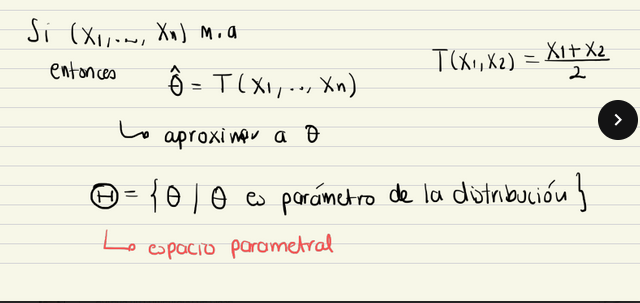

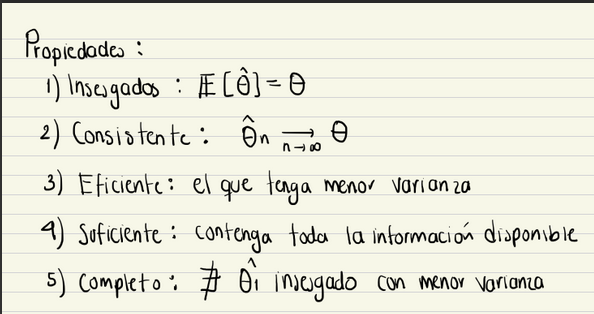

### Métodos para construir estimadores

1. Método de momentos: Igualar los momentos poblacionales con los momentos muestrales.

2. Estimador por máxima verosimilitud

# Método de Máxima Verosimilitud

Tenemos un vector $(x_1,x_2,...x_n)$ y $f(x,\theta)$ es la densidad con su parámetro $\theta$ desconocido a estimar.

La función de verosimilitud es:

$$L(\theta)=∏_{i=1}^{n}f(x_i,\theta)$$

Log-Verosimilitud

$$log(L(\theta))=log(=∏f(x_i,\theta))=\sum log(f(x_i,\theta))$$

Ejemplo 1. Lanzamos una moneda **100** veces, sabiendo que se obtienen **55** soles. Encontrar el EMV para la probabilidad $p$ de obtener un sol en un sólo lanzamiento.

Sea
$$ X: \text{el número de soles que obtienen al lanzar una moneda} $$
tenemos que $X\sim \text{Bin}(100,p)$, entonces
$$f\_{X}(x;p) = \binom{100}{55}p^{55}(1-p)^{100-55}$$


In [31]:
from scipy.stats import binom
import numpy as np

# Vamos a utilizar la libreria SymPy para matemáticas símbolica
import sympy

from sympy.abc import x # importa la variable simbólica x

In [32]:
# Vamos a definir a p como una variable simbólica positiva (de manera manual)
p = sympy.symbols('p', positiva=True)
# Definomps la función de verosimilitud
# omitimos la constante binom{100}{55}
f = p**55 * (1-p)**(100-55)

# Ahora derivamos f con respecto a p
df = sympy.diff(f,p)

# Para encontrar el estimador, igualamos la derivada a cero y despejar p
phat = sympy.solve(df,p)[1] #df=0 para encontra p y [1] para la segunda solución ya que [0] es cero

print("El estimador de máxima verosimilitud para p es", phat)

El estimador de máxima verosimilitud para p es 11/20


Entonces el valor coincide con la proporción de soles.


### Ejemplo

El tiempo de retardo para pacientes con enfermedad coronaria potencial se define como la duración entre el comienzo de un síntoma agudo cardiovascular y la llegada a la unidad de emergencia.

Se supone que el tiempo de retardo sigue una distribución exponencial con parámetro $\theta$.

Se tienen los siguientes registros de retardo (en minutos) en la clinica para los primeros 20 pacientes:

$$ 525, \ 719, \ 2880, \ 150, \ 30, \ 251, \ 45, \ 858, \ 15, \ 47, \ 90, \ 56, \ 68, \ 6, \ 189, \ 180, \ 60, \ 60, \ 294, \ 747 $$

- Encontrar el estimador por el método de momentos para la media
- (Python) Encontrar el valor del estimador con los datos dados.

Se tiene que
$$X : \text{tiempo de retardo (en minutos)} $$
y sigue $\text{Exp}(\theta)$.

Recordemos que $\mathbb{E}[X]=\mu=1/\theta$ y $\text{Var}(X)=1/\theta^{2}$

Por el metodo de momentos, se tiene

$$ \mathbb{E}[X] = \bar{X}$$
En este caso el estiamador para la media es la media muestral.


In [33]:
# Datos observados
datos = np.array([525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747])
# Tamaño de la muestra
n = len(datos)

# El estimador es:
media_muestral = np.mean(datos)
print("La media muestral es:", media_muestral)

La media muestral es: 363.5


Se tiene que $\theta=\frac{1}{\mathbb{E}[X]}$, entonces

$$ \hat{\theta} = \frac{1}{\bar{X}} \approx 0.00275$$
por minuto.

Por lo tanto, estimamos que el **tiempo promedio de retardo** entre el inicio de sintomas cardiovasculares y la llegada a la unidad de emergencia es de aproximadamente 363.5 minutos.


**Ejercicio (Pyton)**. Suponga que la vida util de los focos de cierta marca, se modela mediante una distribución expoencial de parametro $\theta$ (desconocido). Probamos 5 focos y encontramos que tienen una vida útil de $2,3,1,3$ y $5$ años, respectivamente. ¿Cuál es el MLE para $\theta$?

Sabemos que

$$ f(x*i;\theta) = \theta \exp(-\theta x*{i}) , x\ge 0, \theta>0 $$

$$ L(x,\theta) = \prod*{i=1}^{n} f(x_i;\theta) = \prod*{i=1}^{n} \theta \exp(-\theta x\_{i}) = \theta^{n}e^{-\theta \sum x_i}$$

$$ \ln L(x,\theta) = n\ln(\theta)-\theta\sum\_{i}x_i$$

$$\frac{d \ln L(x,\theta)}{d\theta} = \frac{n}{\theta}-\sum_{i}x_i = 0$$

$$ \hat{\theta} = \frac{n}{\sum\_{i}x_i} = 1 / \bar{X} $$


In [34]:
# Datos:
datos = np.array([2,3,1,3,5])
n=len(datos)

suma = np.sum(datos)
media = np.mean(datos)
media

theta = n / suma #(1/media)

print("La media es", media)
print("El estimador de máxima verosimilitud para θ es", theta)


La media es 2.8
El estimador de máxima verosimilitud para θ es 0.35714285714285715


La tasa estimada de falla es de $0.3571$ fallas por año y se tiene que la vida media estimada de los focos es de 2.8 años


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, t, f, norm

# DISTRIBUCIONES MUESTRALES

## Chi-cuadrada ($\chi^2$)

Solo toma valores en $(0,∞)$

Usada para hacer inferencia acerca de la varianza poblacional.

Es asimétrica positiva (cola a la derecha)


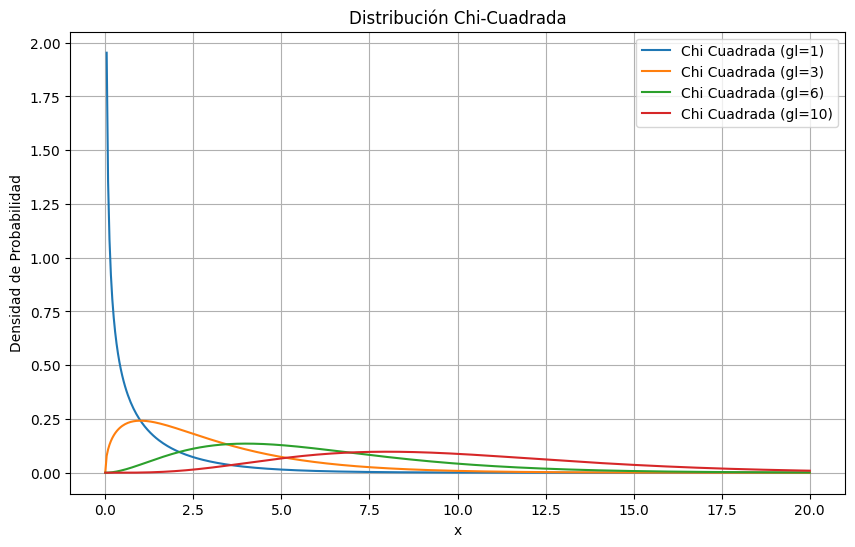

In [36]:
x_chi = np.linspace(0, 20, 500)
plt.figure(figsize=(10, 6))

# Damos los grados de libertad
gl_chi = [1,3,6,10]

for gl in gl_chi:
    plt.plot(x_chi, chi2.pdf(x_chi, gl), label=f'Chi Cuadrada (gl={gl})')
plt.title('Distribución Chi-Cuadrada')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

# t de Student

Cuando no conocemso $\sigma$ y la estimamos con $s$

Simétrica en 0

Colas más pesadas

Cuando n es muy grande es prácticamente normal.

USOS:
Estimar la media poblacional, comparación de dos medias y regresión lineal.



Sea $Z \sim N(0,1)$ independiente de $W \sim \chi^2(n)$. Entonces:
$$t(k) = \frac{Z}{\sqrt{W/n}}$$



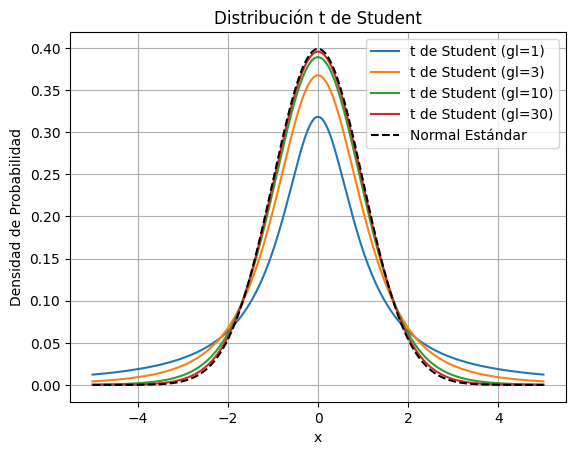

In [37]:
x = np.linspace(-5, 5, 500)

# Grados de libertad
gl_t = [1,3,10,30]

for gl in gl_t:
    plt.plot(x, t.pdf(x, gl), label=f't de Student (gl={gl})')

plt.plot(x,norm.pdf(x),'k--', label='Normal Estándar')
plt.title('Distribución t de Student')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

# F de Fisher

Depende de dos parámetros:

1. Grados de libertad del numerador

2. Grados de libertad del denominador

Sirve para comparar las varianzas poblacionales, ANOVA (análisis de varianza)



Sean $W_1 \sim \chi^2(m)$ y $W_2 \sim \chi^2(n)$ independientes. Entonces:
$$F(m,n) = \frac{W_1/m}{W_2/n} \sim F_{m,n} = F(m,n) $$

- $m$ (grados de libertad numerador), $n$ (denominador)


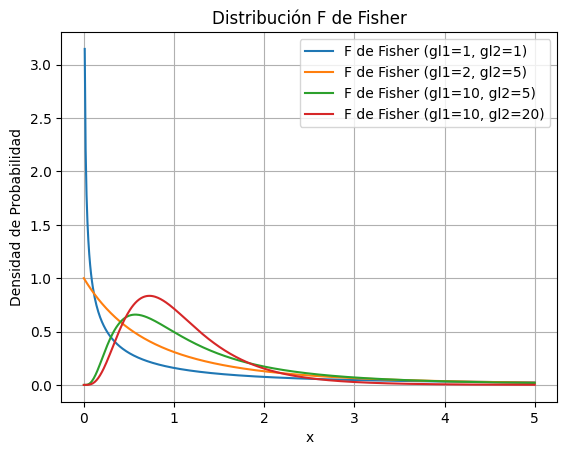

In [38]:
x = np.linspace(0, 5, 500)
# Grados de libertad
gl_f = [(1,1), (2,5), (10,5), (10,20)]
for gl1, gl2 in gl_f:
    plt.plot(x, f.pdf(x, gl1, gl2), label=f'F de Fisher (gl1={gl1}, gl2={gl2})')
plt.title('Distribución F de Fisher')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

# Intervalos de confianza


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

## 1. Intervalo de confianza para la media de una población normal:


Sea $X_1, \dots, X_n$ una m.a $X_i\sim\mathcal{N}(\mu,\sigma^2)$ emtpnces

- $\bar{X} \sim \mathcal{N}(\mu,\sigma^2/n)$
- $Z = \frac{\bar{X}-\mu}{\sigma/n}\sim \mathcal{N}(0,1)$


### - $\sigma$ conocida


Se tiene que el intervalo del $(1-\alpha)x100\%$ de confianza para $\mu$ es:

$$\bar{X} \pm z_{\alpha/2}\frac{\sigma}{\sqrt(n)}$$


**Ejemplo 1** Para tratar de estimar la media de consumo por cliente en un restaurante, se reunieron datos de una muestra de tamaño 49 clientes durante tres semanas.

**a)** Supongamos que la desviación estándar de la población es de $ 2.5 $. ¿Cuál es el error estándar de la media?

**b)** Con un nivel de confianza del 95\%, ¿cuál es el margen de error?

**c)** Si la media de la muestra es de $ 22.60 $, ¿cuál es el intervalo de confianza del 95\% para la media de la población?


In [40]:
n = 49 #clientes
sigma = 2.5 #desviación estándar de la población
media_muestral = 22.60
confianza = 0.95

# a) SE
error_est = sigma / np.sqrt(n)
print(f"Error estándar: {error_est}")

# b) 1 - (1 - confianza) / 2
z = st.norm.ppf(1 - (1 - confianza) / 2)
margen_error = z * error_est
print(f"El margen de error es: {margen_error}")

# c) Intervalo de confianza
lim_inf = media_muestral - margen_error
lim_sup = media_muestral + margen_error
print(f"Intervalo de confianza del {confianza*100}%: ({lim_inf}, {lim_sup})")

Error estándar: 0.35714285714285715
El margen de error es: 0.6999871373357336
Intervalo de confianza del 95.0%: (21.90001286266427, 23.299987137335734)


Tenemos un 95\% de confianza de que el verdadero consumo poblacional en el restaurante se encuentra entre $\$21.90$ y $\$23.30$


**Ejemplo 2** Supongamos que se toma una muestra aleatoria de 100 personas para estimar la media del peso de una población, y se obtiene que la media muestral es de 70 kg con una desviación estándar que es conocida de 10 kg. Para un nivel de confianza del 95\%, calcular el intervalo de confianza.


In [41]:
# Datos
n = 100
sigma = 10
media_muestral = 70
confianza = 0.95
error_est = sigma / np.sqrt(n)

# Utilizaremos la función
# scypy.stats.norm.interval para calcular el intervalo de confianza

intervalo = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"Intervalo de confianza del {confianza*100}%: {intervalo[0]:.2f}, {intervalo[1]:.2f}")

Intervalo de confianza del 95.0%: 68.04, 71.96


Por lo tanto, con un 95% de confianza, estimamos que el peso medio verdadero de la población se encuentra entre $68.04$ y $71.96$


> Se podría practicar modificando el nivel de confianza al $90\%$ o $99\%$ para ver como cambia el intervalo.


### - $\sigma$ desconocida


Se tiene que el intervalo del $(1-\alpha)x 100\%$ de confianza para $\mu$ es:

$$ \bar{X} \pm t\_{\alpha/2}\frac{\sigma}{\sqrt n}$$


**Ejemplo 3** Supongamos que tenemos los siguientes datos de una muestra elatoria de 10 observaciones:

$$ 45,55, 67, 45, 68, 79, 98, 87, 84, 82$$

Clacular un intervalo de confianza para la media


In [42]:
# Datos
datos = np.array([45, 55, 67, 45, 68, 79, 98, 87, 84, 82])

n = len(datos)
confianza = 0.95
gl = n - 1

media_muestral = np.mean(datos)
error_est = st.sem(datos) # error estándar de la media muestral

#Utilizaremos la función
#scipy.stats.t.interval para calcular el intervalo de confianza
intervalo = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est)
print(f"Media muestral: {media_muestral:.2f}")
print(f"Intervalo de confianza del {confianza*100}%: {intervalo[0]:.2f}, {intervalo[1]:.2f}")

Media muestral: 71.00
Intervalo de confianza del 95.0%: 58.00, 84.00


**Ejemplo 4** Los articulos de cerámica utilizados sobre velas eléctricas se rompen con diferentes presiones.
Supongamos que los datos provienen de una distribución normal. La resistencia a la ruptura fue medida con una muestra de 100 articulos y el promedio fue de 1750 con una desviación estandar de 315.8.

**a)** Estimar con un nivel de confianza del $90\%$ a la media poblacional de la presión de la ruptura.

**b)** Estimar con un nivel de confianza del $90\%$ a la varianza poblacional.

$$
\left(\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}}, \frac{(n-1)s^2}{\chi^2_{\alpha/2}}\right)
$$


In [43]:
# Datos
n = 100
confianza = 0.90
gl = n - 1
media_muestral = 1750
desviacion_estandar = 315.8

# a) Utilizamos z ya que n es mayor a 30
error_est = desviacion_estandar / np.sqrt(n)
inttervalo = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"Intervalo de confianza del {confianza*100}% para la media: {inttervalo[0]:.2f}, {inttervalo[1]:.2f}")

# b) IC para la varianza Chi-cuadrada
alpha = 1 - confianza
s2 = desviacion_estandar ** 2 # varianza muestral

# Forma 1. calculando los cuantiles de la chi-cuadrada
chi2_inf = st.chi2.ppf(alpha / 2, gl)
chi2_sup = st.chi2.ppf(1 - alpha / 2, gl)
int_var = ((gl*s2) / chi2_sup,gl*s2/chi2_inf)
print(f"Intervalo de confianza del {confianza*100}% para la varianza: ({int_var[0]:.2f},{int_var[1]:.2f})")

# Forma 2.
chi2_inf,chi2_sup = st.chi2.interval(confianza,gl)
int_var2 = ((gl*s2) / chi2_sup,gl*s2/chi2_inf)
print(f"Intervalo de confianza del {confianza*100}% para la varianza: ({int_var2[0]:.2f},{int_var2[1]:.2f})")


Intervalo de confianza del 90.0% para la media: 1698.06, 1801.94
Intervalo de confianza del 90.0% para la varianza: (80123.49,128146.72)
Intervalo de confianza del 90.0% para la varianza: (80123.49,128146.72)


**Ejercicio 2** Los datos $1.2,\ 2.1,\ 2.3,\ 1.9,\ 3.0,\ 1.5,\ 2.8,\ 2.4,\ 1.7,\ 2.6,\ 2.0,\ 1.8,\ 3.1,\ 2.2,\ 2.5$ se toman a partir de una distribución normal $N(\mu,\sigma^2)$ con $\mu$ desconocida.

**a)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$, dado que $\sigma =2$.

**b)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$.

**c)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\sigma^2$.


In [44]:
# Datos
datos = np.array([1.2, 2.1, 2.3, 1.9, 3.0, 1.5, 2.8, 2.4, 1.7, 2.6, 2.0, 1.8, 3.1, 2.2, 2.5])
n = len(datos)
confianza = 0.90
gl = n - 1
media_muestral = np.mean(datos)

# a) sigma conocida (sigma = 2) con distribución normal
sigma = 2
error_est = sigma / np.sqrt(n)
intervalo_a = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"a) Intervalo de confianza del {confianza*100}% para mu (sigma = {sigma} conocida):({intervalo_a[0]:.2f}, {intervalo_a[1]:.2f})")

# b) sigma desconocida con distribución t de Student
error_est_t = st.sem(datos)
intervalo_b = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est_t)
print(f"b) Intervalo de confianza del {confianza*100}% para mu (sigma desconocida): ({intervalo_b[0]:.2f}, {intervalo_b[1]:.2f})")

# c) IC para la varianza con distribución chi-cuadrada
s2 = np.var(datos)
chi2_inf, chi2_sup = st.chi2.interval(confianza, gl)
int_var = ((gl * s2) / chi2_sup, (gl * s2) / chi2_inf)
print(f"c) Intervalo de confianza del {confianza*100}% para sigma^2: ({int_var[0]:.2f}, {int_var[1]:.2f})")

a) Intervalo de confianza del 90.0% para mu (sigma = 2 conocida):(1.36, 3.06)
b) Intervalo de confianza del 90.0% para mu (sigma desconocida): (1.96, 2.45)
c) Intervalo de confianza del 90.0% para sigma^2: (0.16, 0.59)


# PRUEBAS DE HIPÓTESIS

La prueba de hipótesis es un método estadístico utilizado para determinar si hay suficiente evidencia en una muestra de datos para respaldar o rechazar una suposición específica (hipótesis) sobre una población. Consiste en formular una hipótesis nula (que generalmente indica que no hay efecto o diferencia) y una hipótesis alternativa, para luego analizar los datos de la muestra y decidir si la evidencia es lo suficientemente sólida como para rechazar la hipótesis nula en favor de la alternativa.

## Chi-Cuadrada

La prueba de Chi-cuadrado se utiliza cuando se trabaja con datos categóricos (datos que se dividen en categorías, como “sí” o “no”). Sirve para determinar si existe una relación significativa entre dos variables.

Por ejemplo, se puede emplear una prueba de Chi-cuadrado para analizar si existe una relación entre el género y las preferencias de voto.

    Hipótesis nula (H₀): No hay relación entre el género y las preferencias de voto.
    Hipótesis alternativa (H₁): Sí hay una relación entre el género y las preferencias de voto.


## Pruebas Z y T


Las pruebas Z y prueba T son dos tipos comunes de pruebas de hipótesis utilizadas para comparar medias, pero se aplican en situaciones diferentes.

    Prueba Z: Se usa cuando el tamaño de la muestra es grande (generalmente mayor a 30) y se conoce la desviación estándar de la población.
    Prueba T: Se usa cuando el tamaño de la muestra es pequeño (menos de 30) o la desviación estándar de la población es desconocida.

Ambas pruebas permiten comparar datos de muestra con una media poblacional o comparar las medias de dos muestras entre sí.

Ejemplo 1: Una investigadora en botánica quiere saber si la áltura promedio de cierta especia de planta es igual a 38 cm (hipótesis nula)

Para esto colecta una muestra aleatoria de 12 plantas y registra su altura:

In [51]:
import numpy as np
import scipy.stats as stats

mu = 38.
alpha = 0.05

# Datos definidos directamente como arreglo
data = np.array([
    35.56, 35.56, 40.64, 33.02, 30.48,
    43.18, 38.1, 35.56, 38.1, 33.02,
    38.1, 35.56
])

print(data)

[35.56 35.56 40.64 33.02 30.48 43.18 38.1  35.56 38.1  33.02 38.1  35.56]


In [57]:
import numpy as np
import scipy.stats as stats

mu_0 = 38          # Media
alpha = 0.05

n = len(data)

# Media y desviación estándar muestral
x_bar = np.mean(data)
s = np.std(data, ddof=1)

# Estadístico t
t_stat = (x_bar - mu_0) / (s / np.sqrt(n))

# Valor p (prueba bilateral)
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))

print("PRUEBA DE HIPÓTESIS PARA LA MEDIA")
print("----------------------------------")
print(f"Tamaño de muestra (n): {n}")
print(f"Media muestral: {x_bar:.4f}")
print(f"Desviación estándar: {s:.4f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Decisión
if p_value < alpha:
    print("\nSe rechaza la hipótesis nula.")
    print("La altura promedio es diferente de 38 cm.")
else:
    print("\nSe acepta la hipótesis nula.")
    print("La altura promedio es de 38 cm.")

PRUEBA DE HIPÓTESIS PARA LA MEDIA
----------------------------------
Tamaño de muestra (n): 12
Media muestral: 36.4067
Desviación estándar: 3.4815
Estadístico t: -1.5853
Valor p: 0.1412

Se acepta la hipótesis nula.
La altura promedio es de 38 cm.
